                      Timestamp  Temperature [degC]  Relative humidity [%]  \
0     2018-11-26 07:00:00+00:00           -4.518604              96.456200   
1     2018-11-26 07:10:00+00:00           -4.681363              96.873337   
2     2018-11-26 07:20:00+00:00           -4.879300              96.974167   
3     2018-11-26 07:30:00+00:00           -4.927025              97.301666   
4     2018-11-26 07:40:00+00:00           -4.965400              97.426666   
...                         ...                 ...                    ...   
1052  2018-12-03 14:20:00+00:00           -1.579112              96.272499   
1053  2018-12-03 14:30:00+00:00           -1.487630              96.220001   
1054  2018-12-03 14:40:00+00:00           -1.377834              96.135834   
1055  2018-12-03 14:50:00+00:00           -1.283477              95.991669   
1056  2018-12-03 15:00:00+00:00           -1.257813              95.866669   

      Pressure [hPa]  Solar radiation [W/m^2]  WdSpd - RefHt MM

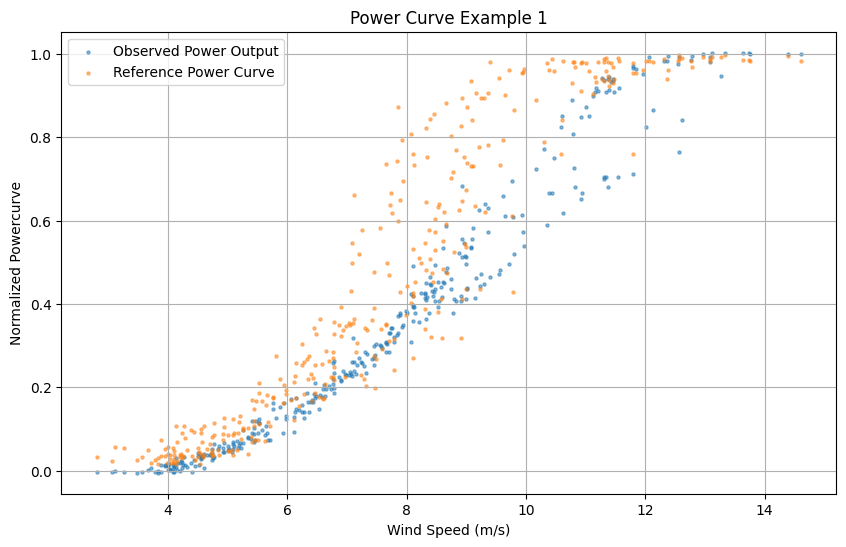

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wind import get_powercurve, fit_power_curve, fit_weibull, get_loss


plt.figure(figsize=(10, 6))

            # Read CSV
df = pd.read_csv("data/Evt1_WEC001-Severe_icing_WEC002-Severe_icing.csv")
print(df)
df = df.dropna(subset=["WdSpd - RefHt WEC001 [m/s]","Power WEC001 Fraction of nomimal power [-]", 'Expected Power WEC002 [-]'])
print(df)
get_powercurve(
    df,
    x_axis="WdSpd - RefHt WEC001 [m/s]",
    y_axis="Power WEC001 Fraction of nomimal power [-]",
    expected_col= 'Expected Power WEC002 [-]',
    title=f"Power Curve Example 1"
)
# powercurve_gain_ref(
#     df,
#     min_points_per_bin = 2
# )
# plt.grid()
plt.savefig("example1.png")
plt.show()  


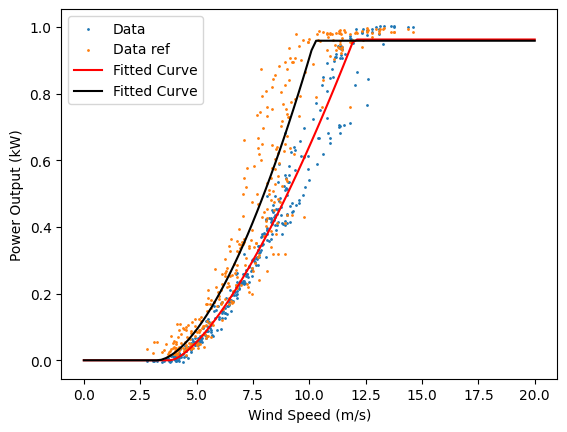

In [2]:
import numpy as np
# Example cubic power curve function

v_fit = np.linspace(0, 20, 100)

wind_speed = df["WdSpd - RefHt WEC001 [m/s]"].to_numpy()

power_output = df["Power WEC001 Fraction of nomimal power [-]"].to_numpy()
power_output_ref = df["Expected Power WEC002 [-]"].to_numpy()

P_rated_fit = fit_power_curve(wind_speed, power_output, v_fit)
P_rated_fit_ref = fit_power_curve(wind_speed, power_output_ref, v_fit)

# Plot
plt.scatter(wind_speed, power_output, label='Data', s = 1)
plt.scatter(wind_speed, power_output_ref, label='Data ref', s = 1)

plt.plot(v_fit, P_rated_fit, label='Fitted Curve', color='red')
plt.plot(v_fit, P_rated_fit_ref, label='Fitted Curve', color='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')
plt.legend()

plt.show()


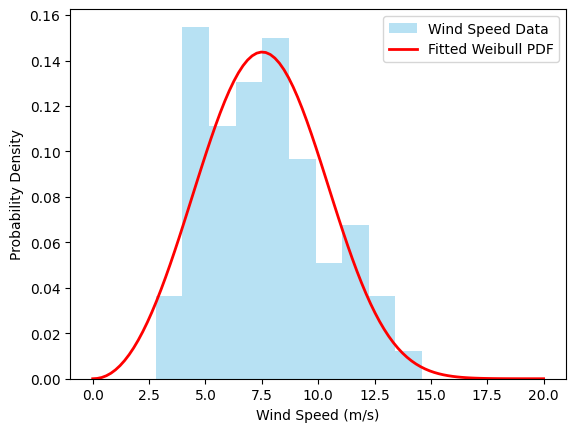

In [3]:

pdf_fitted = fit_weibull(wind_speed, v_fit)
plt.hist(wind_speed, bins=10, density=True, alpha=0.6, color='skyblue', label='Wind Speed Data')
plt.plot(v_fit, pdf_fitted, 'r-', lw=2, label='Fitted Weibull PDF')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [6]:
print(f"Loss = {get_loss(P_rated_fit,P_rated_fit_ref,pdf_fitted,v_fit):.3f}")

Loss = 0.230
